# COVID-19 DATA ANALYSIS

---



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("data/owid-covid-data.csv")
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44780,NaN,NaN,International,2020-09-15,696.0,NaN,NaN,7.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44781,NaN,NaN,International,2020-09-16,696.0,NaN,NaN,7.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44782,NaN,NaN,International,2020-09-17,696.0,NaN,NaN,7.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44783,NaN,NaN,International,2020-09-18,696.0,NaN,NaN,7.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##1. DATA CLEANING
---

In [3]:
df.info()
df.isnull().sum()
df.fillna(0) ##NULL HANDLING
df.duplicated().sum() # duplicated()
df.drop_duplicates() # drop
df = df[df["location"] != "World"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         44521 non-null  object 
 1   continent                        44257 non-null  object 
 2   location                         44785 non-null  object 
 3   date                             44785 non-null  object 
 4   total_cases                      44182 non-null  float64
 5   new_cases                        43982 non-null  float64
 6   new_cases_smoothed               43200 non-null  float64
 7   total_deaths                     44182 non-null  float64
 8   new_deaths                       43982 non-null  float64
 9   new_deaths_smoothed              43200 non-null  float64
 10  total_cases_per_million          43918 non-null  float64
 11  new_cases_per_million            43918 non-null  float64
 12  new_cases_smoothed

In [23]:
df.loc[:,"date"]=pd.to_datetime(df["date"],format="%Y-%m-%d")
df[
  "date"
]#TYPE CASTING

0            2019-12-31
1            2020-01-01
2            2020-01-02
3            2020-01-03
4            2020-01-04
                ...    
44781        2020-09-16
44782        2020-09-17
44783        2020-09-18
44784        2020-09-19
death_rate          NaT
Name: date, Length: 44522, dtype: datetime64[ns]

In [25]:
df.loc[:,"death_rate"]=(df["total_deaths"]/df["total_cases"])
df["death_rate"]

0                  NaN
1                  NaN
2                  NaN
3                  NaN
4                  NaN
                ...   
44781         0.010057
44782         0.010057
44783         0.010057
44784         0.010057
death_rate         NaN
Name: death_rate, Length: 44522, dtype: float64

## DATA ANALYSIS



### 1. Dataset Overview
---


In [15]:
countries=df['location'].unique() # TOTAL COUNTRY IN THIS DATASET
dt_range=df['date'].max()-df['date'].min() # DURATION OF DATA
num=[]
print("TOTAL NUMBER NULLNNES IN DATASET")
for i in df.columns:
  print(i," => ",df[i].isnull().sum())
  if(df[i].dtype=='float64' or df[i].dtype=='int64'):
    num.append(i)
 # TOTAL NUMBER NULLNNES IN DATASET


TOTAL NUMBER NULLNNES IN DATASET
iso_code  =>  264
continent  =>  264
location  =>  0
date  =>  0
total_cases  =>  603
new_cases  =>  803
new_cases_smoothed  =>  1579
total_deaths  =>  603
new_deaths  =>  803
new_deaths_smoothed  =>  1579
total_cases_per_million  =>  867
new_cases_per_million  =>  867
new_cases_smoothed_per_million  =>  1644
total_deaths_per_million  =>  867
new_deaths_per_million  =>  867
new_deaths_smoothed_per_million  =>  1644
new_tests  =>  28874
total_tests  =>  28499
total_tests_per_thousand  =>  28499
new_tests_per_thousand  =>  28874
new_tests_smoothed  =>  26953
new_tests_smoothed_per_thousand  =>  26953
tests_per_case  =>  28372
positive_rate  =>  27988
tests_units  =>  26147
stringency_index  =>  7464
population  =>  264
population_density  =>  2283
median_age  =>  4833
aged_65_older  =>  5425
aged_70_older  =>  5040
gdp_per_capita  =>  5343
extreme_poverty  =>  18463
cardiovasc_death_rate  =>  4818
diabetes_prevalence  =>  3419
female_smokers  =>  13427
ma

### 2. Top 10 Countries by Cases and Death

In [7]:
mk=df.groupby("location")
top10_cases=mk['total_cases'].sum().sort_values(ascending=False).head(10)
top10_deaths=mk['total_deaths'].sum().sort_values(ascending=False).head(10)
print(f"{'='*15}Top 10 Countries by Cases{'='*15}\n{top10_cases}") # RETURN IN FIGURE
print(f"\n{'='*15}Top 10 Countries by Cases{'='*15}\n{top10_deaths}")


===============Top 10 Countries by Cases===============
location
United States     523436049.0
Brazil            278829506.0
India             211519927.0
Russia             96170811.0
Peru               50207019.0
Spain              49782077.0
Mexico             44399655.0
United Kingdom     43905934.0
South Africa       42609907.0
Italy              40735797.0
Name: total_cases, dtype: float64

===============Top 10 Countries by Cases===============
location
United States     20194934.0
Brazil             9969586.0
United Kingdom     5976232.0
Italy              5583789.0
Mexico             4906769.0
France             4666048.0
Spain              4545805.0
India              4198752.0
Iran               2103573.0
Peru               2039742.0
Name: total_deaths, dtype: float64


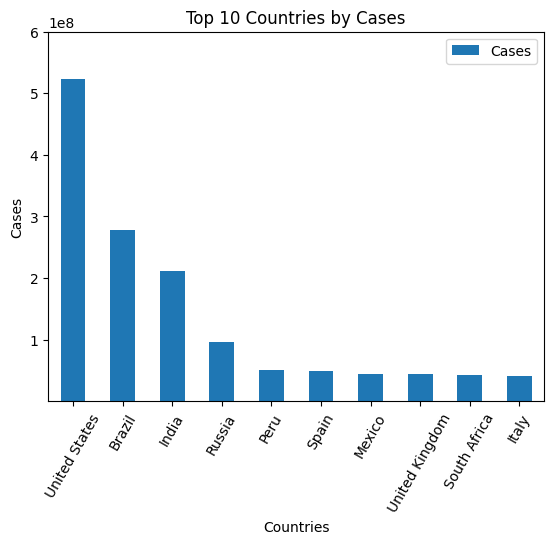

In [8]:
from matplotlib import use
top10_cases.plot(kind="bar")
plt.xlabel("Countries")
plt.ylabel("Cases")
plt.legend(["Cases"])
plt.ylim(1e2,6e8)
plt.xticks(rotation=60)
plt.title("Top 10 Countries by Cases")
plt.show()

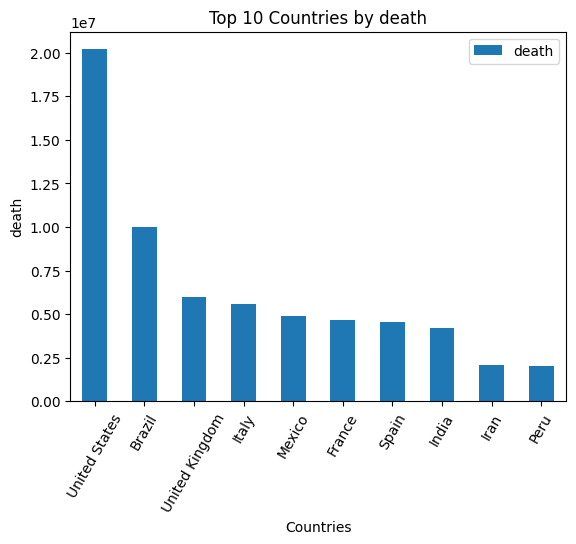

In [9]:
top10_deaths.plot(kind='bar')
plt.xlabel("Countries")
plt.ylabel("death")
plt.legend(["death"])
plt.xticks(rotation=60)
plt.title("Top 10 Countries by death")
plt.show()

### 3. Top Death Rate Countries

================= Top Death Rate Countries =================
location
Yemen                        22.252046
Sint Maarten (Dutch part)    13.818217
France                       12.404625
Sudan                        11.570792
Italy                        11.200430
Belgium                      10.848398
United Kingdom               10.456960
Hungary                      10.285548
Netherlands                   9.778558
Nicaragua                     9.549270
Name: death_rate, dtype: float64


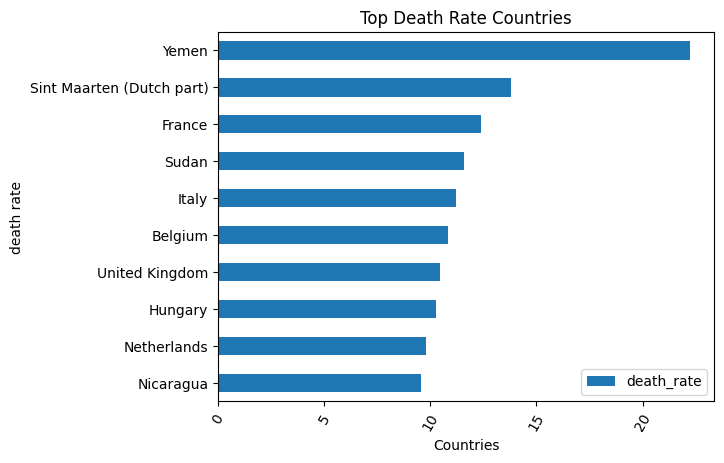

In [10]:
d_rate=mk["death_rate"].mean(
).sort_values(
    ascending=False
    ).head(10)
print(f"{"="*17} Top Death Rate Countries {"="*17}\n{d_rate}")
d_rate[::-1].plot(kind="barh")
plt.xlabel("Countries")
plt.ylabel("death rate")
plt.legend(["death_rate"])
plt.xticks(rotation=60)
plt.title("Top Death Rate Countries")
plt.show()

### 4. Daily Death Trend

================= Daily Death Trend =================
date
2020-09-19    309076.0
2020-09-18    313658.0
2020-09-17    291142.0
2020-09-16    303982.0
2020-09-15    242863.0
2020-09-14    272594.0
2020-09-13    287095.0
2020-09-12    305326.0
2020-09-11    310287.0
2020-09-10    282730.0
Name: new_cases, dtype: float64


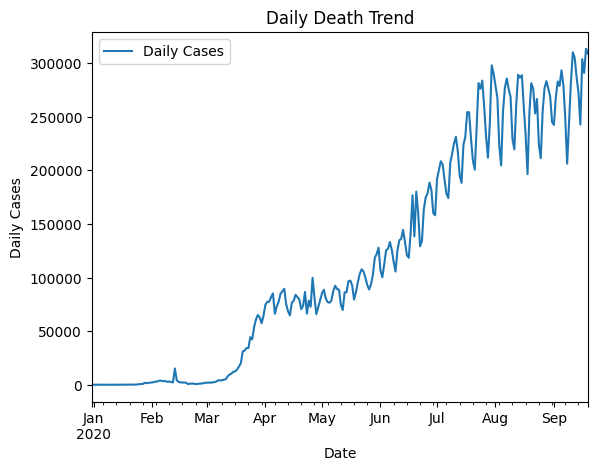

In [11]:
daily = df.groupby("date")["new_cases"].sum().sort_index(ascending=False)
daily10=daily.head(10)
print(f"{'='*17} Daily Death Trend {'='*17}\n{daily10}")
daily.plot()
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.legend(["Daily Cases"])
plt.title("Daily Death Trend")
plt.show()


###5. Monthly Cases

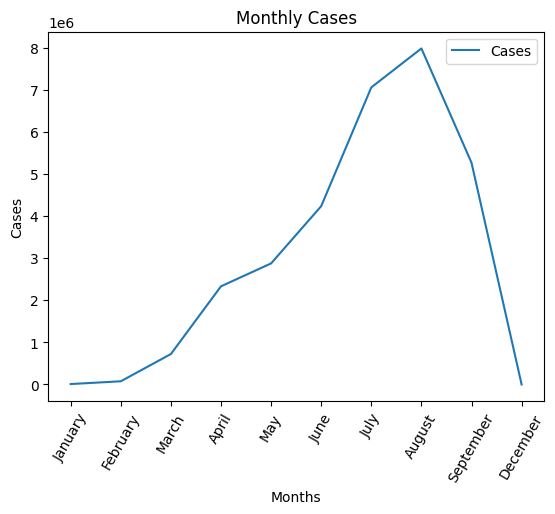

In [12]:
#df['month']=df['date'].dt.month_name()
#df.groupby("month")["new_cases"].sum()
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "December"
]
monthly_cases =df.groupby(df["date"].dt.month
                          )["new_cases"].sum(

                          )

plt.plot(months,monthly_cases.values)
plt.xlabel("Months")
plt.ylabel("Cases")
plt.legend(["Cases"])
plt.title("Monthly Cases")
plt.xticks(rotation=60)
plt.show()

### 6. Cases by Continent

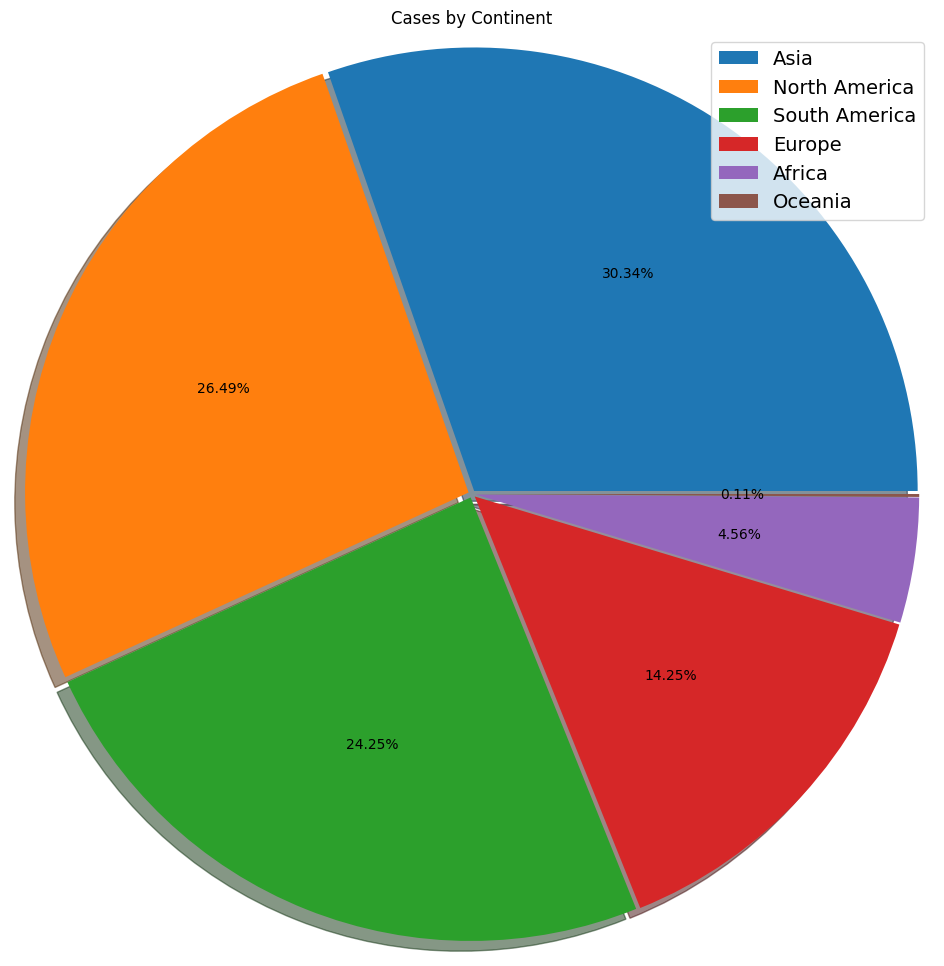

In [13]:
con_data=df.groupby("continent")["new_cases"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 12))
plt.pie(con_data,autopct="%2.2f%%",shadow=True,radius=1.2,explode=[0.01]*len(con_data),)
plt.title("Cases by Continent")
plt.legend(con_data.index,loc="upper right",fontsize=14)
plt.show()
#